In [ ]:
#CELDA 1
import pandas as pd
import numpy as np
import json
import re
import ast
import random
from collections import Counter, defaultdict
from pathlib import Path
import unicodedata
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#CELDA 2
# Parámetros de entrada/salida y control de lectura

# Ruta del Excel en Drive
INPUT_XLSX = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/Pares_anotados.xlsx"
SHEET_NAME = None   #primera hoja

N_ROWS = 501 #current samples in file

OUT_TASK = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/corpus_ext_task.csv"
OUT_PLUS  = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/corpus_ext_plus.csv"
OUT_QC    = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/qc_ext_resumen.txt"

# Reproducibilidad: split y muestreos
RANDOM_SEED = 430
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Proporciones del split
SPLIT_RATIOS = {"train": 0.70, "dev": 0.15, "test": 0.15}

# Columnas en Excel de entrada
EXPECTED_COLS_MIN = ["cluster_id", "role", "sent_quz", "tags"]
OPTIONAL_COLS = ["sent_es", "level"]

In [ ]:
#CELDA 3
def normalize_nfc(s):
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return s
    # Reemplazo de NBSP por espacio normal y normalizacion NFC
    s = str(s).replace("\u00A0", " ")
    s = unicodedata.normalize("NFC", s)
    # Recorte de espacios extremos
    return s.strip()

def parse_tags_cell(x):
    """
    Convierte la celda 'tags' a lista normalizada ['CAT:VAL', ...].
    Acepta: lista Python como texto, lista real, o cadena separada por comas.
    Normaliza '=' a ':' y elimina espacios.
    """
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        raw = x
    else:
        s = str(x).strip()
        try:
            raw = ast.literal_eval(s)
            if not isinstance(raw, list):
                raw = [s]
        except Exception:
            raw = [t for t in s.split(",") if t.strip()]
    norm = []
    for t in raw:
        t = str(t).strip()
        if not t:
            continue
        t = t.replace("=", ":")
        t = re.sub(r"\s+", "", t)
        norm.append(t)
    return norm

def tags_list_to_dict(tags_list):
    """
    ['CAT:VAL', 'BIN'] -> {'CAT': 'VAL', 'BIN': 'YES'}
    Si hay duplicados de categoria, prioriza el ultimo.
    """
    d = {}
    for t in tags_list:
        if ":" in t:
            k, v = t.split(":", 1)
            d[k] = v
        else:
            d[t] = "YES"
    return d

def dict_to_braced_str(d):
    """
    {'A':'x','B':'y'} -> "{A:x, B:y}" con orden alfabetico estable.
    {} -> "{}"
    """
    if not d:
        return "{}"
    items = [f"{k}:{d[k]}" for k in sorted(d.keys())]
    return "{" + ", ".join(items) + "}"

In [ ]:
#CELDA 4

# Alias antiguos a nueva notacion (anterior -> actual)
# Si el valor es:
#   - str  : se reemplaza por esa etiqueta (ej.: "SUBJ=1SG" -> "PERSON:1_SI")
#   - list : se expanden varias etiquetas (ej.: "MOOD=IMP.2SG" -> ["TYPE:IMP","PERSON:2_SI"])
#   - None : se elimina (ej.: "N.NUM=SG" -> None)

ALIAS_MAP = {
    # --- Persona del sujeto (SUBJ=*) ---
    "SUBJ=1SG": "PERSON:1_SI",
    "SUBJ=2SG": "PERSON:2_SI",
    "SUBJ=3SG": "PERSON:3_SI",
    "SUBJ=1PL.INCL": "PERSON:1_PL_INC",
    "SUBJ=1PL.EXCL": "PERSON:1_PL_EXC",
    "SUBJ=2PL": "PERSON:2_PL",
    "SUBJ=3PL": "PERSON:3_PL",

    # --- Tiempo verbal ---
    "TENSE=PRES": "TENSE:PRE_SIM",
    "TENSE=PST.EXP": "TENSE:PST_EXP",
    "TENSE=PST.NEXP": "TENSE:PST_NEXP",
    "TENSE=FUT": "TENSE:FUT_SIM",

    # --- Aspecto ---
    "ASPECT=PROG": "ASPECT:PRG",

    # --- Modo / Tipo de frase (imperativos antiguos como 'MOOD=IMP.*') ---
    "MOOD=COND": "MODE:POT",
    "MOOD=DUB": "MODE:DUB",

    # Imperativo con persona codificada en la etiqueta antigua:
    "MOOD=IMP.2SG": ["TYPE:IMP", "PERSON:2_SI"],
    "MOOD=IMP.3SG": ["TYPE:IMP", "PERSON:3_SI"],
    "MOOD=IMP.1PL.INCL": ["TYPE:IMP", "PERSON:1_PL_INC"],
    "MOOD=IMP.1PL.EXCL": ["TYPE:IMP", "PERSON:1_PL_EXC"],
    "MOOD=IMP.2PL": ["TYPE:IMP", "PERSON:2_PL"],
    "MOOD=IMP.3PL": ["TYPE:IMP", "PERSON:3_PL"],

    # --- Polaridad / Prohibitiva / Interrogacion ---
    "POL=NEG": "TYPE:NEG",
    "POL=PROH": "TYPE:PROH",
    "Q": "SUBTYPE:INT",

    # --- Pronominal (objeto transitivo) ---
    "OBJ=1>2": "PERSON_OBJ:1_SI>2_SI",
    "OBJ=2>1": "PERSON_OBJ:2_SI>1_SI",
    "OBJ=3>1": "PERSON_OBJ:3_SI>1_SI",
    "OBJ=1>3": "PERSON_OBJ:1_SI>3_SI",
    "OBJ=3>2": "PERSON_OBJ:3_SI>2_SI",
    "OBJ=2>3": "PERSON_OBJ:2_SI>3_SI",

    # --- Nominal: numero ---
    "N.NUM=PL": "NUMBER:PL",
    "N.NUM=SG": None,  # se omite: por convencion solo se marca el plural

    # --- Nominal: posesion---
    "POSS=1": "POSS:1_SI",
    "POSS=2": "POSS:2_SI",
    "POSS=3": "POSS:3_SI",

    # --- Evidenciales ---
    "EVID=ATT": "EVID:ATT",
    "EVID=REP": "EVID:REP",
}

def apply_alias_map(tag_list):
    """
    Aplica ALIAS_MAP a una lista de etiquetas.
    - Soporta uno->uno (str), uno->muchos (list) y eliminacion (None).
    - Conserva etiquetas ya modernas (CAT:VAL) si no estan en ALIAS_MAP.
    - Normaliza '=' a ':' y elimina espacios; mantiene el orden de entrada, expandiendo donde corresponda.
    """
    out = []
    for raw in tag_list:
        t = str(raw).strip().replace("=", ":")
        if t in ALIAS_MAP:
            mapped = ALIAS_MAP[t]
            if mapped is None:
                continue
            if isinstance(mapped, list):
                out.extend(mapped)
            else:
                out.append(mapped)
        else:
            out.append(t)
    return out

In [ ]:
#CELDA 5

# Lectura de Excel a DataFrame
read_kwargs = {}
if SHEET_NAME is not None:
    read_kwargs["sheet_name"] = SHEET_NAME
if N_ROWS is not None:
    read_kwargs["nrows"] = N_ROWS

df_raw = pd.read_excel(INPUT_XLSX, **read_kwargs)

# Normalización en columnas
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        df_raw[col] = df_raw[col].map(normalize_nfc)

# Verificación de columnas mínimas
missing = set(EXPECTED_COLS_MIN) - set(df_raw.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas en el Excel: {sorted(missing)}")

# Mantener solo columnas relevantes
cols_keep = [c for c in EXPECTED_COLS_MIN + OPTIONAL_COLS if c in df_raw.columns]
df = df_raw[cols_keep].copy()

# Normalizar role
df["role"] = df["role"].astype(str).str.strip().str.lower()

# Parsear y normalizar tags (SIN alias antiguos)
df["tags"] = df["tags"].apply(parse_tags_cell)

group = df.groupby("cluster_id", sort=True)["role"].apply(list)
clusters_no_base = [cid for cid, roles in group.items() if "base" not in [r.lower() for r in roles]]
if clusters_no_base:
    print("Advertencia: clusters sin fila base:", clusters_no_base)

# Duplicados exactos (mismo cluster_id, role, sent_quz)
dup_mask = df.duplicated(subset=["cluster_id", "role", "sent_quz"], keep=False)
if dup_mask.any():
    print("Advertencia: filas duplicadas exactas detectadas. Se recomienda inspección manual.")

Advertencia: filas duplicadas exactas detectadas. Se recomienda inspección manual.


In [ ]:
#CELDA 6

def compute_change(source_dict, target_dict):
    """
    Devuelve:
      - change_obj: dict con SOLO categorías cuyo valor aparece/cambia en el target.
      - change_delta: dict textual src->tgt para auditoría (incluye removidas con NA).
      - removed_cats: lista de categorías que estaban en source y desaparecen en target.
    """
    change_obj = {}
    change_delta = {}
    removed_cats = []

    cats = sorted(set(source_dict.keys()) | set(target_dict.keys()))
    for k in cats:
        sv = source_dict.get(k, None)
        tv = target_dict.get(k, None)
        if sv != tv:
            if tv is not None:
                change_obj[k] = tv
            else:
                removed_cats.append(k)
            s_show = "NA" if sv is None else sv
            t_show = "NA" if tv is None else tv
            change_delta[k] = f"{s_show}->{t_show}"

    # --- Regla de anclaje de PERSON (se mantiene) ---
    # Solo forzar PERSON si el Change contiene TENSE o MODE o TYPE:IMP y PERSON existe en target
    if (("TENSE" in change_obj) or ("MODE" in change_obj) or (change_obj.get("TYPE") == "IMP")) \
       and ("PERSON" in target_dict) and ("PERSON" not in change_obj):
        # PERSON no cambió (si hubiese cambiado ya estaría en change_obj)
        change_obj["PERSON"] = target_dict["PERSON"]

    return change_obj, change_delta, removed_cats

# Orden de presentación del CHANGE
CHANGE_ORDER = ["PERSON", "NUMBER", "POSS", "TENSE", "ASPECT", "PERSON_OBJ","MODE", "TYPE", "SUBTYPE", "EVID"]

def order_change_keys(d):
    keys = list(d.keys())
    keys.sort(key=lambda k: (CHANGE_ORDER.index(k) if k in CHANGE_ORDER else 999, k))
    return {k: d[k] for k in keys}

# ---------------------------
# NUEVO: helpers para validar pares según los dos criterios acordados
# ---------------------------

def _tam_star_present(tags_dict):
    """
    True si el conjunto de tags contiene al menos un miembro de TAM*:
      - TENSE:* (cualquier valor)
      - MODE:{POT, DUB}
      - TYPE:IMP
    """
    if "TENSE" in tags_dict:
        return True
    if tags_dict.get("MODE") in {"POT", "DUB"}:
        return True
    if tags_dict.get("TYPE") == "IMP":
        return True
    return False

def _cooccurrence_person_tam_ok(tags_dict):
    """
    Co-ocurrencia PERSON <-> TAM*
    Válido si:
      - ambos presentes, o
      - ambos ausentes.
    Inválido si:
      - PERSON presente y TAM* ausente, o
      - TAM* presente y PERSON ausente.
    """
    has_person = ("PERSON" in tags_dict)
    has_tamstar = _tam_star_present(tags_dict)
    return (has_person and has_tamstar) or (not has_person and not has_tamstar)

def _is_in_TAM_star(cat, val):
    """
    True si (cat,val) pertenece a TAM*:
      - cat == "TENSE" (cualquier val)
      - cat == "MODE"  y val in {"POT","DUB"}
      - cat == "TYPE"  y val == "IMP"
    """
    if cat == "TENSE":
        return True
    if cat == "MODE" and val in {"POT", "DUB"}:
        return True
    if cat == "TYPE" and val == "IMP":
        return True
    return False

def _pair_is_valid(tags_source_dict, tags_target_dict, change_delta_dict):
    """
    Implementa EXACTAMENTE los dos criterios acordados:

    (1) Co-ocurrencia PERSON <-> TAM* en source y target.
    (2) Si hay al mismo tiempo al menos una desaparición (VAL->NA) y al menos una aparición (NA->VAL),
        solo es válido si TODAS esas desapariciones y apariciones están dentro de TAM*.
        En cualquier otro caso, se descarta.
    """
    # (1) Co-ocurrencia en source y target
    if not _cooccurrence_person_tam_ok(tags_source_dict):
        return False, "violates_person_tam_cooccurrence_source"
    if not _cooccurrence_person_tam_ok(tags_target_dict):
        return False, "violates_person_tam_cooccurrence_target"

    # (2) Patrón de desaparición + aparición simultáneas
    removals = []   # [(cat, val_src)]
    additions = []  # [(cat, val_tgt)]
    for cat, delta in change_delta_dict.items():
        try:
            s_val, t_val = delta.split("->", 1)
        except Exception:
            # Formato inesperado; no invalidamos por esto.
            continue
        s_val = s_val.strip()
        t_val = t_val.strip()
        if s_val != "NA" and t_val == "NA":
            removals.append((cat, s_val))
        elif s_val == "NA" and t_val != "NA":
            additions.append((cat, t_val))

    if removals and additions:
        # Validar que TODO lo que desaparece y aparece está dentro de TAM*
        only_tamstar = True
        for cat, v in removals:
            if not _is_in_TAM_star(cat, v):
                only_tamstar = False
                break
        if only_tamstar:
            for cat, v in additions:
                if not _is_in_TAM_star(cat, v):
                    only_tamstar = False
                    break
        if not only_tamstar:
            return False, "removed_and_appeared_outside_TAM_star"

    # Si no hay simultáneas (o todo dentro de TAM*), el par es válido
    return True, "ok"

rows_task = []
rows_plus = []

# Auditorías:
qc_logs_removed   = []  # etiquetas removidas en pares incluidos
qc_logs_empty     = []  # pares descartados por Change vacío
qc_logs_filtered  = []  # NUEVO: pares descartados por las dos reglas acordadas

for cid, g in df.groupby("cluster_id", sort=True):
    # Construir lista de filas del cluster (incluye base y transformadas)
    rows = []
    for _, rr in g.iterrows():
        entry = {
            "role": rr["role"],
            "sent_quz": rr["sent_quz"],
            "sent_es": rr["sent_es"] if "sent_es" in g.columns else None,
            "tags_list": rr["tags"],
            "tags_dict": tags_list_to_dict(rr["tags"]),
        }
        rows.append(entry)

    # Generar todas las parejas dirigidas i -> j con i != j
    for i in range(len(rows)):
        for j in range(len(rows)):
            if i == j:
                continue

            src = rows[i]
            tgt = rows[j]

            source_quz = src["sent_quz"]
            target_quz = tgt["sent_quz"]
            source_es  = src["sent_es"]
            target_es  = tgt["sent_es"]

            tags_source_list = src["tags_list"]
            tags_target_list = tgt["tags_list"]
            tags_source_dict = src["tags_dict"]
            tags_target_dict = tgt["tags_dict"]

            change_obj, change_delta, removed_cats = compute_change(tags_source_dict, tags_target_dict)
            change_obj = order_change_keys(change_obj)
            change_str = dict_to_braced_str(change_obj)
            change_delta_str = dict_to_braced_str(change_delta)

            # Si el Change queda vacío, descartamos este par y lo registramos
            if not change_obj:
                qc_logs_empty.append({
                    "cluster_id": cid,
                    "reason": "empty_change_only_disappearing_tags_or_none",
                    "source_snip": (source_quz[:80] if isinstance(source_quz, str) else str(source_quz)),
                    "target_snip": (target_quz[:80] if isinstance(target_quz, str) else str(target_quz)),
                    "tags_source": json.dumps(sorted(tags_source_list), ensure_ascii=False),
                    "tags_target": json.dumps(sorted(tags_target_list), ensure_ascii=False),
                    "delta": change_delta_str
                })
                continue  # no agregamos al corpus

            # NUEVO: Validación por los dos criterios acordados
            is_valid, reason = _pair_is_valid(tags_source_dict, tags_target_dict, change_delta)
            if not is_valid:
                qc_logs_filtered.append({
                    "cluster_id": cid,
                    "reason": reason,
                    "delta": change_delta_str,
                    "source_snip": (source_quz[:80] if isinstance(source_quz, str) else str(source_quz)),
                    "target_snip": (target_quz[:80] if isinstance(target_quz, str) else str(target_quz)),
                    "tags_source": json.dumps(sorted(tags_source_list), ensure_ascii=False),
                    "tags_target": json.dumps(sorted(tags_target_list), ensure_ascii=False),
                })
                continue  # descartado por criterios acordados

            # Log de etiquetas removidas (para revisión manual) SOLO si el par se incluye
            if removed_cats:
                qc_logs_removed.append({
                    "cluster_id": cid,
                    "removed": ",".join(sorted(removed_cats)),
                    "delta": change_delta_str,
                    "source_snip": (source_quz[:80] if isinstance(source_quz, str) else str(source_quz)),
                    "target_snip": (target_quz[:80] if isinstance(target_quz, str) else str(target_quz)),
                })

            # --- Agregar filas a TASK y PLUS ---
            rows_task.append({
                # id se asignará más adelante
                "source_quz": source_quz,
                "change": change_str,
                "target_quz": target_quz,
            })

            row_plus = {
                "cluster_id": cid,
                "source_quz": source_quz,
                "target_quz": target_quz,
                "change_obj": change_str,
                "change_delta": change_delta_str,
                "tags_source": json.dumps(sorted(tags_source_list)),
                "tags_target": json.dumps(sorted(tags_target_list)),
                "pos_source": None,
                "pos_target": None,
            }
            if "sent_es" in df.columns:
                row_plus["source_es"] = source_es
                row_plus["target_es"] = target_es

            rows_plus.append(row_plus)

task_df = pd.DataFrame(rows_task, columns=["source_quz","change","target_quz"])
plus_df = pd.DataFrame(rows_plus)

In [ ]:
#CELDA 7

# Mapeo de categorias a un grupo primario para el split
PRIMARY_MAP = {
    "PERSON": "PERSON",
    "NUMBER": "NUMBER",
    "POSS":   "POSS",
    "TENSE":  "TENSE",
    "ASPECT": "ASPECT",
    "MODE":   "MODE",
    "TYPE":   "TYPE",
    "SUBTYPE":"SUBTYPE",
    "EVID":   "EVID",
}

def parse_change_to_dict(change_str):
    """
    "{A:x, B:y}" -> {"A":"x", "B":"y"}; "{}" -> {}
    """
    s = change_str.strip()
    if s == "{}":
        return {}
    s = s.strip("{}").strip()
    if not s:
        return {}
    parts = [p for p in s.split(",") if p.strip()]
    out = {}
    for p in parts:
        if ":" in p:
            k, v = p.split(":", 1)
            out[k.strip()] = v.strip()
    return out

def primary_change(change_dict):
    """
    Categoria primaria para estratificar. Se toma la primera segun CHANGE_ORDER.
    """
    if not change_dict:
        return "NONE"
    for k in CHANGE_ORDER:
        if k in change_dict:
            return PRIMARY_MAP.get(k, k)
    return sorted(change_dict.keys())[0]

def assign_level(change_dict):
    """
    Regla de niveles basada en Cap. 4 (resumen operativo):
      - 4: si incluye evidenciales (EVID) o combinaciones extensas (>=3 familias distintas) con TAM
      - 3: si incluye TENSE:PST_NEXP o modos (MODE) o imperativo/otras TYPE complejas
      - 2: si incluye TENSE:FUT_SIM, TENSE:PST_EXP, ASPECT:PRG, o marcas de objeto (no modeladas aqui)
      - 1: cambios locales (PERSON, POSS, NUMBER, TYPE:NEG, SUBTYPE:INT) o combinaciones leves
    Nota: si hay multiples categorias, se eleva el nivel segun max de las presentes.
    """
    if not change_dict:
        return 1

    cats = set(change_dict.keys())

    if "EVID" in cats:
        return 4
    fams = set(PRIMARY_MAP.get(c, c) for c in cats)
    if ("TENSE" in fams or "ASPECT" in fams or "MODE" in fams) and len(fams) >= 3:
        return 4
    tense_val = change_dict.get("TENSE", "")
    if tense_val == "PST_NEXP":
        return 3
    if "MODE" in cats:
        return 3
    if change_dict.get("TYPE", "") in {"IMP", "PROH"}:
        return 3
    if tense_val in {"FUT_SIM", "PST_EXP"}:
        return 2
    if "ASPECT" in cats:
        return 2
    return 1

task_df["change_dict"] = task_df["change"].map(parse_change_to_dict)
task_df["level"] = task_df["change_dict"].map(assign_level)
task_df["primary_change"] = task_df["change_dict"].map(primary_change)

plus_df["change_dict"] = plus_df["change_obj"].map(parse_change_to_dict)
plus_df["level"] = plus_df["change_dict"].map(assign_level)
plus_df["primary_change"] = plus_df["change_dict"].map(primary_change)

In [ ]:
# CELDA 8

# HINTS morpho rules (English, plug-and-play, surface forms only).
# KEY RULE: PERSON is always contextualized with the TARGET's TAM/MOOD/IMP.
# If the target has TENSE (FUT/PST_EXP/PST_NEXP), MODE (POT/DUB) or TYPE:IMP,
# the PERSON line uses the specific table for that context.
# Only when the target has no TAM/MOOD/IMP, PERSON uses present endings.

import json, ast

def _parse_tags_json_to_dict(tags_json):
    """
    tags_json: string with JSON list of 'CAT:VAL', e.g. '["PERSON:3_SI","TENSE:FUT_SIM"]'
    -> dict {'CAT':'VAL', ...}
    """
    try:
        arr = ast.literal_eval(tags_json) if isinstance(tags_json, str) else (tags_json or [])
    except Exception:
        arr = []
    d = {}
    for t in arr:
        t = str(t).strip()
        if ":" in t:
            k, v = t.split(":", 1)
            d[k] = v
        else:
            d[t] = "YES"
    return d

def make_hints(change_dict, target_tags_dict):
    """
    Build a list of concise hints based on change_dict,
    but conjugation-sensitive categories (PERSON) are contextualized
    using the TARGET tags (target_tags_dict).
    Output: json.dumps(list[str])
    """
    hints = []

    # ---------------------------
    # Base tables
    # ---------------------------

    # Present (no explicit TAM/Mood/Imp)
    PERSON_PRESENT = {
        "1_SI": "PERSON:1_SI -> attach 'ni' to the verb",
        "2_SI": "PERSON:2_SI -> attach 'nki' to the verb",
        "3_SI": "PERSON:3_SI -> attach 'n' to the verb",
        "1_PL_INC": "PERSON:1_PL_INC -> attach 'nchik' to the verb",
        "1_PL_EXC": "PERSON:1_PL_EXC -> attach 'yku' to the verb",
        "2_PL": "PERSON:2_PL -> attach 'nki chik' to the verb",
        "3_PL": "PERSON:3_PL -> attach 'n ku' to the verb",
    }

    # FUT simple
    FUT_MAP = {
        "1_SI":  "TENSE:FUT_SIM + PERSON:1_SI -> 'saq'",
        "2_SI":  "TENSE:FUT_SIM + PERSON:2_SI -> 'nki'",
        "3_SI":  "TENSE:FUT_SIM + PERSON:3_SI -> 'nqa'",
        "1_PL_INC":"TENSE:FUT_SIM + PERSON:1_PL_INC -> 'su nchik'",
        "1_PL_EXC":"TENSE:FUT_SIM + PERSON:1_PL_EXC -> 'saq ku'",
        "2_PL":  "TENSE:FUT_SIM + PERSON:2_PL -> 'nki chik'",
        "3_PL":  "TENSE:FUT_SIM + PERSON:3_PL -> 'nqa ku'",
    }

    # PST experiencial
    PST_EXP_MAP = {
        "1_SI":  "TENSE:PST_EXP + PERSON:1_SI -> 'rqa ni'",
        "2_SI":  "TENSE:PST_EXP + PERSON:2_SI -> 'rqa nki'",
        "3_SI":  "TENSE:PST_EXP + PERSON:3_SI -> 'rqa n'",
        "1_PL_INC":"TENSE:PST_EXP + PERSON:1_PL_INC -> 'rqa nchik'",
        "1_PL_EXC":"TENSE:PST_EXP + PERSON:1_PL_EXC -> 'rqa yku'",
        "2_PL":  "TENSE:PST_EXP + PERSON:2_PL -> 'rqa nki chik'",
        "3_PL":  "TENSE:PST_EXP + PERSON:3_PL -> 'rqa n ku'",
    }

    # PST no experiencial (3_SI no agrega -n)
    PST_NEXP_MAP = {
        "1_SI":  "TENSE:PST_NEXP + PERSON:1_SI -> 'sqa ni'",
        "2_SI":  "TENSE:PST_NEXP + PERSON:2_SI -> 'sqa nki'",
        "3_SI":  "TENSE:PST_NEXP + PERSON:3_SI -> 'sqa'",
        "1_PL_INC":"TENSE:PST_NEXP + PERSON:1_PL_INC -> 'sqa nchik'",
        "1_PL_EXC":"TENSE:PST_NEXP + PERSON:1_PL_EXC -> 'sqa yku'",
        "2_PL":  "TENSE:PST_NEXP + PERSON:2_PL -> 'sqa nki chik'",
        "3_PL":  "TENSE:PST_NEXP + PERSON:3_PL -> 'sqa ku'",
    }

    # Aspect
    ASPECT_PRG = "ASPECT:PRG -> add 'chka' to the verb"

    # Mode POT
    POT_MAP = {
        "1_SI":  "MODE:POT + PERSON:1_SI -> 'y man'",
        "2_SI":  "MODE:POT + PERSON:2_SI -> 'nki man'",
        "3_SI":  "MODE:POT + PERSON:3_SI -> 'n man'",
        "1_PL_INC":"MODE:POT + PERSON:1_PL_INC -> 'su nchik man'",
        "1_PL_EXC":"MODE:POT + PERSON:1_PL_EXC -> 'yku man'",
        "2_PL":  "MODE:POT + PERSON:2_PL -> 'nki chik man'",
        "3_PL":  "MODE:POT + PERSON:3_PL -> 'n ku man'",
    }

    # Mode DUB (forma principal según manual)
    DUB_MAP = {
        "1_SI":  "MODE:DUB + PERSON:1_SI -> 'y man chus'",
        "2_SI":  "MODE:DUB + PERSON:2_SI -> 'waq chus'",
        "3_SI":  "MODE:DUB + PERSON:3_SI -> 'n man chus'",
        "1_PL_INC":"MODE:DUB + PERSON:1_PL_INC -> 'su nchik man chus'",
        "1_PL_EXC":"MODE:DUB + PERSON:1_PL_EXC -> 'yku man chus'",
        "2_PL":  "MODE:DUB + PERSON:2_PL -> 'waq chik chus'",
        "3_PL":  "MODE:DUB + PERSON:3_PL -> 'n ku man chus'",
    }

    # Imperative TYPE:IMP
    IMP_MAP = {
        "2_SI":  "TYPE:IMP + PERSON:2_SI -> 'y'",
        "3_SI":  "TYPE:IMP + PERSON:3_SI -> 'chun'",
        "1_PL_INC":"TYPE:IMP + PERSON:1_PL_INC -> 'su nchik'",
        "1_PL_EXC":"TYPE:IMP + PERSON:1_PL_EXC -> 'saq ku'",
        "2_PL":  "TYPE:IMP + PERSON:2_PL -> 'y chik'",
        "3_PL":  "TYPE:IMP + PERSON:3_PL -> 'chun ku'",
    }

    # Direct object agreement (transitive)
    PO_MAP = {
        "1_SI>2_SI": "PERSON_OBJ:1_SI>2_SI -> add 'yki' on the transitive verb",
        "2_SI>1_SI": "PERSON_OBJ:2_SI>1_SI -> add 'wa nki' on the transitive verb",
        "3_SI>1_SI": "PERSON_OBJ:3_SI>1_SI -> add 'wa n' on the transitive verb",
        "1_SI>3_SI": "PERSON_OBJ:1_SI>3_SI -> add 'ni' on the transitive verb",
        "3_SI>2_SI": "PERSON_OBJ:3_SI>2_SI -> add 'su nki' on the transitive verb",
        "2_SI>3_SI": "PERSON_OBJ:2_SI>3_SI -> add 'nki' on the transitive verb",
    }

    # Possession (epenthetic -ni- before person suffix on C-final nouns)
    POSS_MAP = {
        "1_SI":      ["POSS:1_SI -> noun(V-final): 'y'",           "POSS:1_SI -> noun(C-final): 'ni y'"],
        "2_SI":      ["POSS:2_SI -> noun(V-final): 'yki'",         "POSS:2_SI -> noun(C-final): 'ni yki'"],
        "3_SI":      ["POSS:3_SI -> noun(V-final): 'n'",           "POSS:3_SI -> noun(C-final): 'ni n'"],
        "1_PL_INC":  ["POSS:1_PL_INC -> noun(V-final): 'nchik'",   "POSS:1_PL_INC -> noun(C-final): 'ni nchik'"],
        "1_PL_EXC":  ["POSS:1_PL_EXC -> noun(V-final): 'yku'",     "POSS:1_PL_EXC -> noun(C-final): 'ni yku'"],
        "2_PL":      ["POSS:2_PL -> noun(V-final): 'yki chik'",    "POSS:2_PL -> noun(C-final): 'ni yki chik'"],
        "3_PL":      ["POSS:3_PL -> noun(V-final): 'n ku'",        "POSS:3_PL -> noun(C-final): 'ni n ku'"],
    }

    # Evidentials
    EVID_MAP = {
        "ATT": "EVID:ATT -> attach 'mi' after consonants / 'm' after vowels; place it on the focused NP before the verb",
        "REP": "EVID:REP -> attach 'si' after consonants / 's' after vowels",
    }

    # Negation / Prohibitive
    TYPE_NEG  = "TYPE:NEG -> pattern 'mana' ... 'chu' (preserve arguments)"
    TYPE_PROH = "TYPE:PROH -> pattern 'ama' ... 'chu' (prohibitive)"

    # SUBTYPE (interrogative)
    SUBTYPE_INT = "SUBTYPE:INT -> pattern '... chu'"

    # Number
    NUMBER_PL = "NUMBER:PL -> add 'kuna' to the head noun; do not pluralize proper names/topics"

    # ---------------------------
    # Target context
    # ---------------------------
    # NOTE: we will not use target context to add PERSON hints unless PERSON is in change
    t_person = target_tags_dict.get("PERSON") if isinstance(target_tags_dict, dict) else None
    t_tense  = target_tags_dict.get("TENSE")  if isinstance(target_tags_dict, dict) else None
    t_mode   = target_tags_dict.get("MODE")   if isinstance(target_tags_dict, dict) else None
    t_type   = target_tags_dict.get("TYPE")   if isinstance(target_tags_dict, dict) else None

    # ---------------------------
    # Hints driven by change_dict
    # ---------------------------

    # NUMBER
    if change_dict.get("NUMBER") == "PL":
        hints.append(NUMBER_PL)

    # POSS
    poss_val = change_dict.get("POSS")
    if poss_val in POSS_MAP:
        hints.extend(POSS_MAP[poss_val])

    # EVID
    evid_val = change_dict.get("EVID")
    if evid_val in EVID_MAP:
        hints.append(EVID_MAP[evid_val])

    # TYPE NEG/PROH
    type_val = change_dict.get("TYPE")
    if type_val == "NEG":
        hints.append(TYPE_NEG)
    elif type_val == "PROH":
        hints.append(TYPE_PROH)

    # SUBTYPE (e.g. interrogative)
    subtype_val = change_dict.get("SUBTYPE")
    if subtype_val == "INT":
        hints.append(SUBTYPE_INT)

    # ASPECT
    if change_dict.get("ASPECT") == "PRG":
        hints.append(ASPECT_PRG)

    # PERSON_OBJ
    po_val = change_dict.get("PERSON_OBJ")
    if po_val in PO_MAP:
        hints.append(PO_MAP[po_val])

    # ---------------------------
    # PERSON + (TAM/MOOD/IMP) — restricted to change only
    # ---------------------------
    tense_in_change = change_dict.get("TENSE")
    mode_in_change  = change_dict.get("MODE")
    type_in_change  = change_dict.get("TYPE")

    if "PERSON" in change_dict:
        p = change_dict.get("PERSON")
        # Priority: IMP > MODE > TENSE > present
        if type_in_change == "IMP":
            rule = IMP_MAP.get(p)
            if rule: hints.append(rule)
        elif mode_in_change == "POT":
            rule = POT_MAP.get(p)
            if rule: hints.append(rule)
        elif mode_in_change == "DUB":
            rule = DUB_MAP.get(p)
            if rule: hints.append(rule)
        elif tense_in_change == "FUT_SIM":
            rule = FUT_MAP.get(p)
            if rule: hints.append(rule)
        elif tense_in_change == "PST_EXP":
            rule = PST_EXP_MAP.get(p)
            if rule: hints.append(rule)
        elif tense_in_change == "PST_NEXP":
            rule = PST_NEXP_MAP.get(p)
            if rule: hints.append(rule)
        else:
            rule = PERSON_PRESENT.get(p)
            if rule: hints.append(rule)

    return json.dumps(hints, ensure_ascii=True)

# Build target tag dict and generate hints
plus_df["_tags_target_dict"] = plus_df["tags_target"].apply(_parse_tags_json_to_dict)
plus_df["hints"] = plus_df.apply(lambda row: make_hints(row["change_dict"], row["_tags_target_dict"]), axis=1)
plus_df = plus_df.drop(columns=["_tags_target_dict"], errors="ignore")

In [ ]:
#CELDA 9

# Asignar id consecutivo a cada fila
task_df = task_df.reset_index(drop=True)
task_df.insert(0, "id", range(1, len(task_df) + 1))

plus_df = plus_df.reset_index(drop=True)
plus_df.insert(0, "id", range(1, len(plus_df) + 1))

In [ ]:
#CELDA 10

# Pares por cluster
pairs_plus = plus_df[["id","cluster_id","primary_change","level"]].copy()

# Bins por par (categoria primaria x nivel)
pairs_plus["bin"] = pairs_plus["primary_change"].astype(str) + "::" + pairs_plus["level"].astype(str)

# Conteo deseado por bin segun ratios
bin_counts = pairs_plus["bin"].value_counts().to_dict()
desired = {b: {
    "train": int(round(cnt * SPLIT_RATIOS["train"])),
    "dev":   int(round(cnt * SPLIT_RATIOS["dev"])),
    "test":  cnt - int(round(cnt * SPLIT_RATIOS["train"])) - int(round(cnt * SPLIT_RATIOS["dev"]))
} for b, cnt in bin_counts.items()}

# Vistas por cluster: cuantos pares aporta a cada bin
cluster_bins = defaultdict(lambda: Counter())
for _, row in pairs_plus.iterrows():
    cluster_bins[row["cluster_id"]][row["bin"]] += 1

# Greedy assignment por cluster para aproximar los objetivos por bin
splits = {"train": Counter(), "dev": Counter(), "test": Counter()}
cluster_split = {}

# Ordenar clusters por cantidad total de pares
clusters_sorted = sorted(cluster_bins.keys(), key=lambda c: sum(cluster_bins[c].values()), reverse=True)

def split_cost_if_assign(splt, bins_counter):
    cost = 0
    for b, add in bins_counter.items():
        current = splits[splt][b]
        want = desired.get(b, {"train":0,"dev":0,"test":0})[splt]
        over = max(0, (current + add) - want)
        cost += over
    return cost

for cid in clusters_sorted:
    bins_counter = cluster_bins[cid]
    costs = {s: split_cost_if_assign(s, bins_counter) for s in splits.keys()}
    best_split = min(costs.items(), key=lambda kv: (kv[1], sum(splits[kv[0]].values())))[0]
    cluster_split[cid] = best_split
    for b, n in bins_counter.items():
        splits[best_split][b] += n

# Asignar split a cada fila segun cluster_id
plus_df["split"] = plus_df["cluster_id"].map(cluster_split)

tmp_join = plus_df[["id","split"]].set_index("id")
task_df["split"] = task_df["id"].map(tmp_join["split"])

In [ ]:
#CELDA 11

# Recalcular (por coherencia final antes de volcar)
task_df["change_dict"] = task_df["change"].map(parse_change_to_dict)
task_df["level"] = task_df["change_dict"].map(assign_level)
task_df["primary_change"] = task_df["change_dict"].map(primary_change)

plus_df["change_dict"] = plus_df["change_obj"].map(parse_change_to_dict)
plus_df["level"] = plus_df["change_dict"].map(assign_level)
plus_df["primary_change"] = plus_df["change_dict"].map(primary_change)

# corpus_task.csv
task_cols = ["id", "source_quz", "change", "target_quz", "level", "split"]
task_out = task_df[task_cols].copy()
task_out.to_csv(OUT_TASK, index=False, encoding="utf-8")

# corpus_plus.csv
plus_cols = [
    "id", "cluster_id",
    "source_quz", "target_quz",
    "change_obj", "change_delta",
    "tags_source", "tags_target",
    "level", "split",
]
if "source_es" in plus_df.columns:
    plus_cols.insert(3, "source_es")
    plus_cols.insert(5, "target_es")
plus_cols.extend(["pos_source","pos_target","hints"])

plus_out = plus_df[plus_cols].copy()
plus_out.to_csv(OUT_PLUS, index=False, encoding="utf-8")

# QC: removed tags (included pairs) + empty-change exclusions (discarded pairs) + NUEVO: filtered por reglas acordadas
try:
    with open(OUT_QC, "w", encoding="utf-8") as f:
        f.write("# QC LOG — removed tags in included pairs\n")
        f.write("# cluster_id | removed | delta | source_snip | target_snip\n")
        for rec in qc_logs_removed:
            f.write(f"{rec['cluster_id']}\t{rec['removed']}\t{rec['delta']}\t{rec['source_snip']}\t{rec['target_snip']}\n")
        f.write("\n# QC LOG — discarded pairs due to empty change\n")
        f.write("# cluster_id | reason | delta | source_snip | target_snip | tags_source | tags_target\n")
        for rec in qc_logs_empty:
            f.write(f"{rec['cluster_id']}\t{rec['reason']}\t{rec['delta']}\t{rec['source_snip']}\t{rec['target_snip']}\t{rec['tags_source']}\t{rec['tags_target']}\n")
        f.write("\n# QC LOG — discarded pairs due to agreed filters (PERSON<->TAM* and removal+appearance outside TAM*)\n")
        f.write("# cluster_id | reason | delta | source_snip | target_snip | tags_source | tags_target\n")
        for rec in qc_logs_filtered:
            f.write(f"{rec['cluster_id']}\t{rec['reason']}\t{rec['delta']}\t{rec['source_snip']}\t{rec['target_snip']}\t{rec['tags_source']}\t{rec['tags_target']}\n")
    wrote_qc = True
except Exception as e:
    wrote_qc = False
    print("Aviso: no se pudo escribir OUT_QC:", e)

print("Archivos escritos en UTF-8:")
print(f"- {OUT_TASK} -> {len(task_out)} filas")
print(f"- {OUT_PLUS} -> {len(plus_out)} filas")
if wrote_qc:
    print(f"- {OUT_QC} -> removed:{len(qc_logs_removed)} | discarded_empty:{len(qc_logs_empty)} | filtered:{len(qc_logs_filtered)}")

Archivos escritos en UTF-8:
- /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/corpus_ext_task.csv -> 6328 filas
- /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/corpus_ext_plus.csv -> 6328 filas
- /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/qc_ext_resumen.txt -> removed:1767 | discarded_empty:196 | filtered:2422


In [ ]:
# === LECTURA Y TABLAS DE ANÁLISIS (task y plus) ===
import pandas as pd
import numpy as np

# Rutas
OUT_TASK = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/corpus_ext_task.csv"
OUT_PLUS = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/corpus_ext_plus.csv"

task_df = pd.read_csv(OUT_TASK)
plus_df = pd.read_csv(OUT_PLUS)

CHANGE_ORDER = ["TENSE", "PERSON","NUMBER","POSS","ASPECT","MODE","TYPE","SUBTYPE","EVID", "PERSON_OBJ"]

def parse_change_to_dict(change_str: str):
    s = str(change_str).strip()
    if s == "{}":
        return {}
    s = s.strip("{}").strip()
    if not s:
        return {}
    parts = [p for p in s.split(",") if p.strip()]
    out = {}
    for p in parts:
        if ":" in p:
            k, v = p.split(":", 1)
            out[k.strip()] = v.strip()
    return out

def primary_change(change_dict: dict):
    if not change_dict:
        return "NONE"
    for k in CHANGE_ORDER:
        if k in change_dict:
            return k
    return sorted(change_dict.keys())[0]

# --- Derivados para task ---
task_df["change_dict"] = task_df["change"].map(parse_change_to_dict)
task_df["primary_change"] = task_df["change_dict"].map(primary_change)

# --- Derivados para plus ---
plus_df["change_dict"] = plus_df["change_obj"].map(parse_change_to_dict)
plus_df["primary_change"] = plus_df["change_dict"].map(primary_change)

# ============== TABLAS ==============

# 1) Distribución por split (task vs plus)
split_task = task_df["split"].value_counts().reindex(["train","dev","test"]).fillna(0).astype(int)
split_plus = plus_df["split"].value_counts().reindex(["train","dev","test"]).fillna(0).astype(int)
tbl_split = pd.DataFrame({"task": split_task, "plus": split_plus})
tbl_split.index.name = "split"

# 2) Distribución por nivel (task vs plus)
lvl_task = task_df["level"].value_counts().sort_index()
lvl_plus = plus_df["level"].value_counts().sort_index()
tbl_level = pd.DataFrame({"task": lvl_task, "plus": lvl_plus}).fillna(0).astype(int)
tbl_level.index.name = "level"

# 3) Frecuencia de categorías (keys) en 'change' (task)
def change_key_counts(df, change_col="change"):
    def keys_in_change(s):
        d = parse_change_to_dict(s)
        return list(d.keys())
    all_keys = []
    for s in df[change_col]:
        all_keys.extend(keys_in_change(s))
    return pd.Series(all_keys).value_counts().rename("freq")

tbl_cat = change_key_counts(task_df, "change").to_frame()
tbl_cat["pct"] = (tbl_cat["freq"] / tbl_cat["freq"].sum() * 100).round(2)

# 4) Top combinaciones de categorías (task)
def change_combo_counts(df, change_col="change"):
    def keys_tuple(s):
        d = parse_change_to_dict(s)
        return tuple(sorted(d.keys())) if d else tuple()
    combos = df[change_col].map(keys_tuple)
    return pd.Series(combos).value_counts()

tbl_combos = change_combo_counts(task_df, "change").to_frame(name="freq").reset_index()
tbl_combos.columns = ["combo_keys", "freq"]
tbl_combos = tbl_combos.head(15)  # top-15

# 5) Matriz primary_change × level (task)
tbl_pc_level = task_df.groupby(["primary_change","level"]).size().unstack(fill_value=0)
tbl_pc_level = tbl_pc_level.loc[sorted(tbl_pc_level.index)]

# 6) Promedio de pares por cluster (plus)
avg_per_cluster = plus_df.groupby("cluster_id").size().mean()
tbl_avg_cluster = pd.DataFrame({"metric":["avg_pairs_per_cluster"], "value":[round(float(avg_per_cluster),2)]})

# --- Mostrar tablas de forma compacta ---
print("Tabla A. Distribución por split (task vs plus)")
display(tbl_split)

print("\nTabla B. Distribución por nivel (task vs plus)")
display(tbl_level)

print("\nTabla C. Frecuencia de categorías en 'change' (task)")
display(tbl_cat)

print("\nTabla D. Top-15 combinaciones de categorías en 'change' (task)")
display(tbl_combos)

print("\nTabla E. Matriz primary_change × level (task)")
display(tbl_pc_level)

print("\nTabla F. Promedio de pares por cluster (plus)")
display(tbl_avg_cluster)

Tabla A. Distribución por split (task vs plus)


,task,plus
split,,
train,4259,4259
dev,935,935
test,1134,1134



Tabla B. Distribución por nivel (task vs plus)


,task,plus
level,,
1,2854,2854
2,703,703
3,446,446
4,2325,2325



Tabla C. Frecuencia de categorías en 'change' (task)


...

,combo_keys,freq
0,"(PERSON,)",1290
1,"(PERSON, TENSE)",1053
2,"(PERSON, POSS)",661
3,"(PERSON, POSS, TENSE)",501
4,"(EVID, PERSON, TENSE)",478
5,"(POSS,)",301
6,"(MODE, PERSON)",196
7,"(MODE, PERSON, POSS)",154
8,"(EVID, PERSON)",146
9,"(EVID,)",130



Tabla E. Matriz primary_change × level (task)


level,1,2,3,4
primary_change,,,,
ASPECT,0,26,0,4
EVID,0,0,0,132
NUMBER,30,0,0,3
PERSON,2223,42,276,450
PERSON_OBJ,10,0,0,0
POSS,307,1,0,100
SUBTYPE,17,0,0,0
TENSE,249,634,170,1632
TYPE,18,0,0,4



Tabla F. Promedio de pares por cluster (plus)


,metric,value
0,avg_pairs_per_cluster,158.2


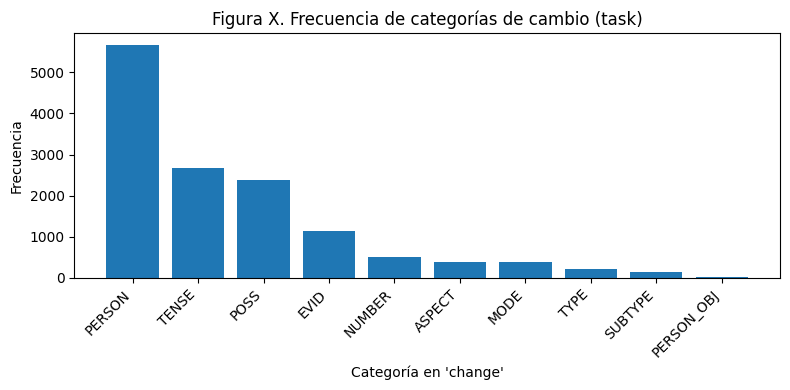

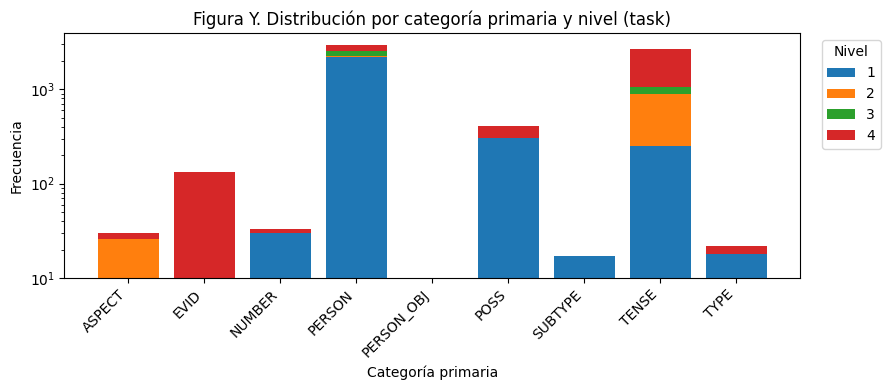

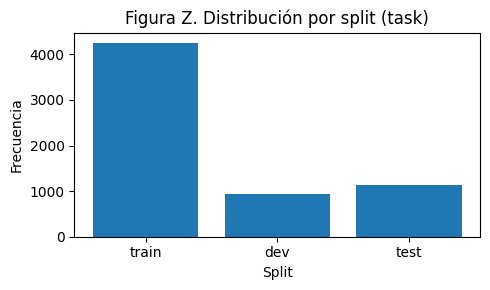

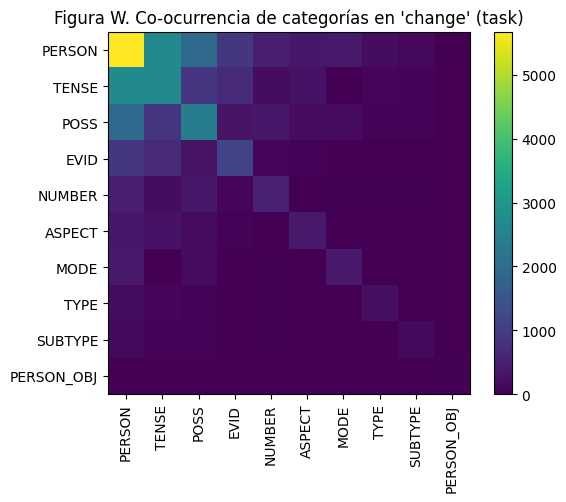

In [ ]:
# === FIGURAS ===
import matplotlib.pyplot as plt
import numpy as np

# 1) Barras: frecuencia de categorías (task)
keys = tbl_cat.index.tolist()
vals = tbl_cat["freq"].tolist()

plt.figure(figsize=(8,4))
plt.bar(keys, vals)
plt.title("Figura X. Frecuencia de categorías de cambio (task)")
plt.xlabel("Categoría en 'change'")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2) Barras apiladas: primary_change × level (task) — ESCALA LOGARÍTMICA
pc_level_vals = tbl_pc_level.values
levels = tbl_pc_level.columns.tolist()
idx = np.arange(len(tbl_pc_level))

plt.figure(figsize=(9,4))
bottom = np.zeros(len(tbl_pc_level))
for i, lvl in enumerate(levels):
    plt.bar(idx, tbl_pc_level[lvl].values, bottom=bottom, label=str(lvl))
    bottom += tbl_pc_level[lvl].values

plt.title("Figura Y. Distribución por categoría primaria y nivel (task)")
plt.xlabel("Categoría primaria")
plt.ylabel("Frecuencia")
plt.xticks(idx, tbl_pc_level.index, rotation=45, ha="right")
plt.yscale("log")              # << cambio clave
plt.legend(title="Nivel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Barras: distribución por split (task)
plt.figure(figsize=(5,3))
plt.bar(tbl_split.index, tbl_split["task"].values)
plt.title("Figura Z. Distribución por split (task)")
plt.xlabel("Split")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# 4) Heatmap simple de co-ocurrencia de categorías (task)
cats = tbl_cat.index.tolist()
cat_index = {c:i for i,c in enumerate(cats)}
M = np.zeros((len(cats), len(cats)), dtype=int)

for s in task_df["change"]:
    d = parse_change_to_dict(s)
    k = list(d.keys())
    for i in range(len(k)):
        for j in range(i, len(k)):
            a, b = cat_index[k[i]], cat_index[k[j]]
            M[a,b] += 1
            if a != b:
                M[b,a] += 1

plt.figure(figsize=(6,5))
plt.imshow(M, interpolation="nearest")
plt.title("Figura W. Co-ocurrencia de categorías en 'change' (task)")
plt.xticks(range(len(cats)), cats, rotation=90)
plt.yticks(range(len(cats)), cats)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# === TABLAS UNIFICADAS: distribución de etiquetas CAT:VAL (FIX) ===

import pandas as pd

# 0) Construir un DF expandido: una fila por etiqueta+valor (catval) y por ejemplo
records = []
for _, row in task_df.iterrows():
    d = parse_change_to_dict(row["change"])
    for k, v in d.items():
        records.append({
            "catval": f"{k}:{v}",
            "split": row["split"],
            "level": row["level"],
        })
df_catval = pd.DataFrame(records)

# 1) Tabla global: conteo y % por CAT:VAL
tbl_catval_all = df_catval["catval"].value_counts().to_frame(name="freq")
tbl_catval_all["pct"] = (tbl_catval_all["freq"] / tbl_catval_all["freq"].sum() * 100).round(2)

# 2) Desglose por split (una sola tabla pivote CAT:VAL × split)
tbl_catval_split = df_catval.pivot_table(
    index="catval", columns="split", values="level", aggfunc="count", fill_value=0
).sort_index()

# 3) Desglose por level (una sola tabla pivote CAT:VAL × level)
tbl_catval_level = df_catval.pivot_table(
    index="catval", columns="level", values="split", aggfunc="count", fill_value=0
).sort_index()

print("Tabla G*. Distribución global por etiqueta+valor (CAT:VAL)")
display(tbl_catval_all)

print("\nTabla H*. Distribución por etiqueta+valor desglosada por split")
display(tbl_catval_split)

print("\nTabla I*. Distribución por etiqueta+valor desglosada por level")
display(tbl_catval_level)

Tabla G*. Distribución global por etiqueta+valor (CAT:VAL)


,freq,pct
catval,,
PERSON:3_SI,1460,10.77
PERSON:3_PL,1163,8.58
TENSE:FUT_SIM,854,6.30
TENSE:PRE_SIM,750,5.53
PERSON:2_SI,689,5.08
PERSON:1_SI,657,4.85
TENSE:PST_EXP,612,4.52
EVID:ATT,594,4.38
PERSON:1_PL_INC,583,4.30



Tabla H*. Distribución por etiqueta+valor desglosada por split


split,dev,test,train
catval,,,
ASPECT:PRG,98,72,227
EVID:ATT,51,166,377
EVID:REP,36,142,363
MODE:DUB,0,15,156
MODE:POT,0,18,198
NUMBER:PL,9,122,388
PERSON:1_PL_EXC,121,37,421
PERSON:1_PL_INC,121,48,414
PERSON:1_SI,147,62,448



Tabla I*. Distribución por etiqueta+valor desglosada por level


level,1,2,3,4
catval,,,,
ASPECT:PRG,0,69,0,328
EVID:ATT,0,0,0,594
EVID:REP,0,0,0,541
MODE:DUB,0,0,76,95
MODE:POT,0,0,120,96
NUMBER:PL,264,0,0,255
PERSON:1_PL_EXC,284,67,26,202
PERSON:1_PL_INC,284,69,26,204
PERSON:1_SI,302,90,19,246


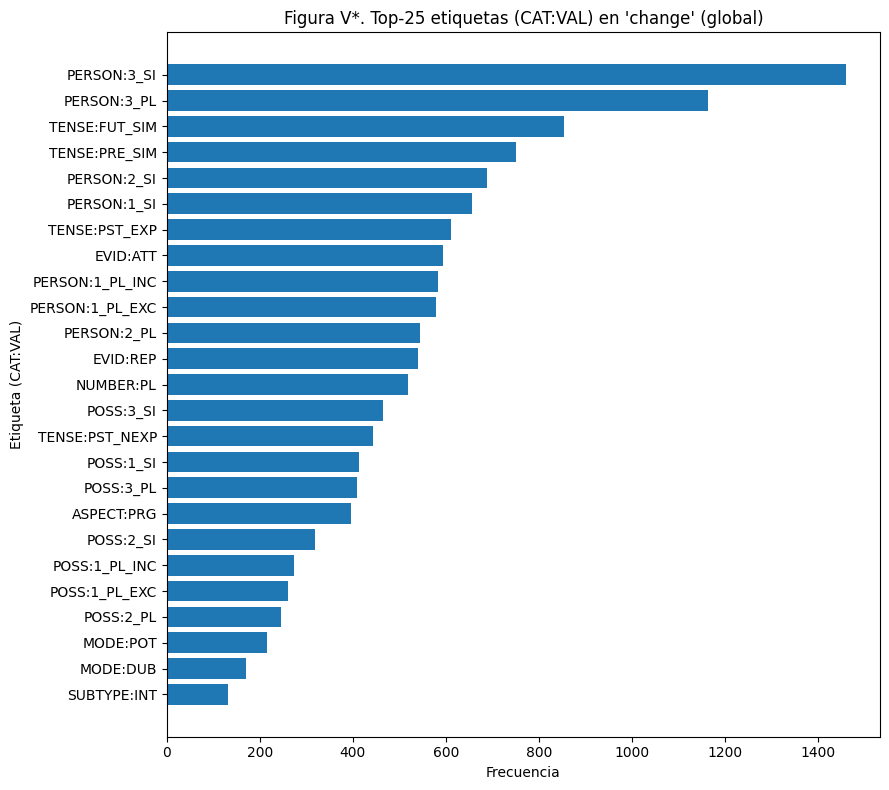

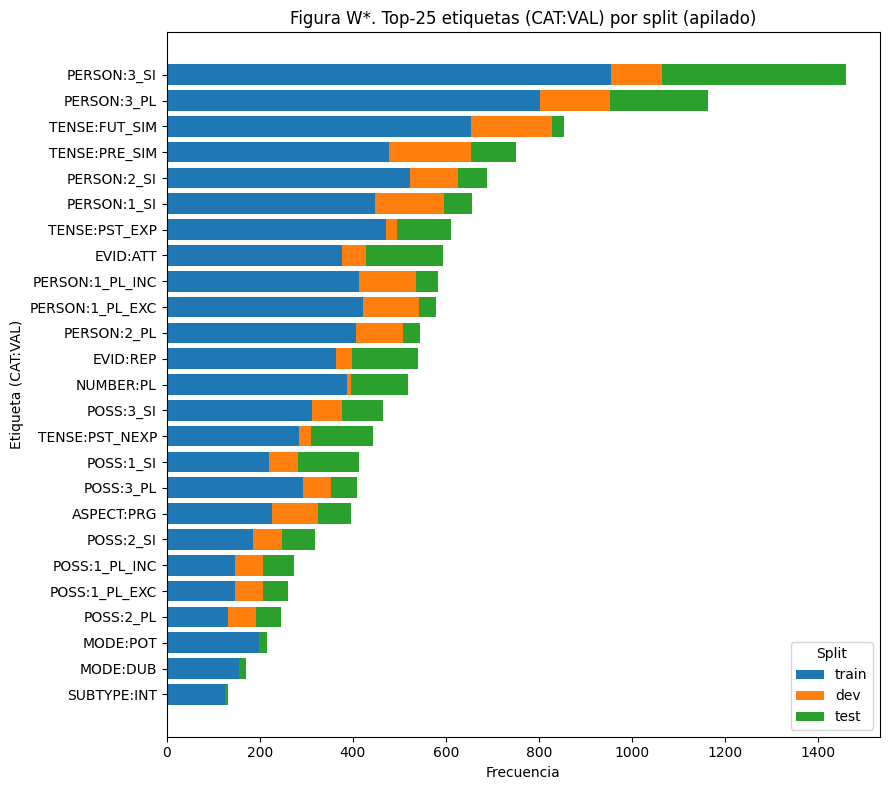

In [ ]:
# === FIGURAS UNIFICADAS: distribución CAT:VAL (FIX) ===
import matplotlib.pyplot as plt
import numpy as np

TOP_N = 25  # ajusta si quieres más/menos etiquetas

# --- A) Figura: Top-N CAT:VAL GLOBAL ---
top_catval = tbl_catval_all.head(TOP_N).iloc[::-1]  # horizontal ascendente

plt.figure(figsize=(9, 8))
plt.barh(top_catval.index, top_catval["freq"].values)
plt.title(f"Figura V*. Top-{TOP_N} etiquetas (CAT:VAL) en 'change' (global)")
plt.xlabel("Frecuencia")
plt.ylabel("Etiqueta (CAT:VAL)")
plt.tight_layout()
plt.show()

# --- B) Figura: Top-N CAT:VAL con desglose por split (apilado) ---
labels = top_catval.index.tolist()
split_cols = [c for c in ["train","dev","test"] if c in tbl_catval_split.columns]
stack_mat = tbl_catval_split.reindex(labels).fillna(0)[split_cols].values

plt.figure(figsize=(9, 8))
bottom = np.zeros(len(labels))
for i, sp in enumerate(split_cols):
    vals = stack_mat[:, i]
    plt.barh(labels, vals, left=bottom, label=sp)
    bottom += vals

plt.title(f"Figura W*. Top-{TOP_N} etiquetas (CAT:VAL) por split (apilado)")
plt.xlabel("Frecuencia")
plt.ylabel("Etiqueta (CAT:VAL)")
plt.legend(title="Split", loc="lower right")
plt.tight_layout()
plt.show()